# Mapping chimera data on atlas

In [1]:
# Load packages
suppressPackageStartupMessages({
    library(ggplot2)
    library(biomaRt)
    library(BiocParallel)
    library(Matrix)
    library(matrixStats)
    library(scater)
    library(reshape2)
    library(knitr)
    library(scran)
    library(harmony)
    library(reticulate)
    library(SingleCellExperiment)
    library(data.table)
    library(dplyr)
    library(gridExtra)
})
    ncores = 4
    mcparam = MulticoreParam(workers = ncores)
    register(mcparam)

options(repr.plot.width=15, repr.plot.height=8)

In [193]:
main = "/rds/project/rds-SDzz0CATGms/users/bt392/phd_01_Eomes_RNA/"
out_dir = paste0(main, '07_atlas_mapping/')
plot_dir = paste0(main, '07_atlas_mapping/plots/')
dir.create(out_dir, showWarnings = FALSE)
dir.create(plot_dir, showWarnings = FALSE)

atlas_in = '/rds/project/rds-SDzz0CATGms/users/bt392/mouse/Mixl1_KO/atlas/atlas/'

source(paste0(main, "core_functions.R"))

In [3]:
# UMAP before batch correction
# Running UMAP from python
source_python(paste0(main, 'UMAP_R_to_py.py'))
run_umap = function(pca_in){
    umap = as.data.frame(umap_redu(pca_in))
    colnames(umap) = c('umap_1', 'umap_2')
   # rownames(umap) = big_meta$cell
    return(umap)    
}

In [4]:
plot_umap = function(umap){
p1 = ggplot(umap[27987:nrow(umap),], aes(umap_1, umap_2, col= as.factor(atlas_meta$celltype))) + 
        scale_colour_manual(values = celltype_colours, name = "celltype") +
        geom_point(alpha = 0.2) + 
        theme(text = element_text(size = 30),
                axis.text.y   = element_blank(),
                axis.text.x   = element_blank(),
                axis.title.y  = element_blank(),
                axis.title.x  = element_blank(),
                axis.ticks = element_blank(),
                legend.position = "none",
                panel.background = element_blank(),
                panel.grid.major = element_blank(), 
                panel.grid.minor = element_blank(),
                panel.border = element_rect(colour = "black", fill=NA, size=1)) +
        guides(colour = guide_legend(override.aes = list(alpha = 1)))

p2 = ggplot(umap[0:27986,], aes(umap_1, umap_2, col= as.factor(meta$tdTom))) + 
        geom_point(alpha = 0.2) + 
        scale_colour_manual(values = c('negative' = 'black', 'positive' = 'red'), name = "Tomato") + 
        theme(text = element_text(size = 30),
                axis.text.y   = element_blank(),
                axis.text.x   = element_blank(),
                axis.title.y  = element_blank(),
                axis.title.x  = element_blank(),
                axis.ticks = element_blank(),
                legend.position = "none",
                panel.background = element_blank(),
                panel.grid.major = element_blank(), 
                panel.grid.minor = element_blank(),
                panel.border = element_rect(colour = "black", fill=NA, size=1)) +
        guides(colour = guide_legend(override.aes = list(alpha = 1)))

p3 = ggplot(umap, aes(umap_1, umap_2, col= as.factor(big_meta$exp))) + 
        geom_point(alpha = 0.2) + 
        theme(text = element_text(size = 30),
                axis.text.y   = element_blank(),
                axis.text.x   = element_blank(),
                axis.title.y  = element_blank(),
                axis.title.x  = element_blank(),
                axis.ticks = element_blank(),
                legend.position = "none",
                panel.background = element_blank(),
                panel.grid.major = element_blank(), 
                panel.grid.minor = element_blank(),
                panel.border = element_rect(colour = "black", fill=NA, size=1)) +
        guides(colour = guide_legend(override.aes = list(alpha = 1)))
    grid.arrange(p3, p1, p2, ncol = 3)
}

In [ ]:
load_data(normalise = FALSE, remove_doublets = TRUE, remove_stripped = TRUE)
meta$batch = as.factor(meta$batch)
meta$cell = paste0('chim_', meta$cell)

# Atlas 
atlas_in = '/rds/project/rds-SDzz0CATGms/users/bt392/mouse/Mixl1_KO/atlas/atlas/'
atlas_counts = readMM(paste0(atlas_in, 'raw_counts.mtx')) # readMM for .mtx input 
atlas_genes = read.table(paste0(atlas_in, 'genes.tsv'), stringsAsFactors = F)
atlas_meta = read.table(paste0(atlas_in, 'meta.tab'), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
atlas_meta$cell <- paste0('atlas_', atlas_meta$cell)

In [3]:
# filter atlas cells
atlas_sce = SingleCellExperiment(assays = list("counts" = atlas_counts))
atlas_sce = atlas_sce[,!atlas_meta$doublet]
atlas_meta = atlas_meta[!atlas_meta$doublet,]
atlas_sce = atlas_sce[,!atlas_meta$stripped]
atlas_meta = atlas_meta[!atlas_meta$stripped,]

In [4]:
# make sure gene sets overlap
shared_genes = merge(genes, atlas_genes, by='V1')
sce = sce[shared_genes$V1,]
#atlas_sce = atlas_sce[shared_genes$V1,]

In [5]:
# extract count matrix chim
chim_counts = counts(sce)
colnames(chim_counts) = paste0('chim_', colnames(chim_counts))

In [6]:
# extract count matrix atlas
atlas_counts = counts(atlas_sce)
rownames(atlas_counts) = atlas_genes[,1] #ensembl
colnames(atlas_counts) = atlas_meta$cell

dimnames(.) <- NULL:  translated to 
dimnames(.) <- list(NULL,NULL)  <==>  unname(.)



In [7]:
# concatenate count matrices
big_counts = cbind(chim_counts, atlas_counts)
saveRDS(big_counts, file = paste0(out_dir,"big_counts.rds"))

In [8]:
# create big SCE object
big_sce = SingleCellExperiment(assays = list("counts" = big_counts))
saveRDS(big_sce, file = paste0(out_dir,"big_sce.rds"))

In [42]:
big_sce

class: SingleCellExperiment 
dim: 29452 144298 
metadata(0):
assays(1): counts
rownames(29452): ENSMUSG00000000001 ENSMUSG00000000003 ...
  ENSMUSG00000114189 ENSMUSG00000114192
rowData names(0):
colnames(144298): cell_1 cell_2 ... '' ''
colData names(0):
reducedDimNames(0):
altExpNames(0):

### Create metadata 
Match the shared columns into one dataframe for metadata

### process

In [9]:
# calculate sizefactors
clusts = as.numeric(quickCluster(big_sce, method = "igraph", min.size = 100, BPPARAM = mcparam))
min.clust = min(table(clusts))/2
new_sizes = c(floor(min.clust/3), floor(min.clust/2), floor(min.clust))
big_sce = computeSumFactors(big_sce, clusters = clusts, sizes = new_sizes, max.cluster.size = 3000)
write.table(sizeFactors(big_sce), quote = F, col.names = F, row.names = F, file = paste0(out_dir,"sizefactors_big.tab"))

ERROR: Error in paste0(out_folder, "sizefactors_big.tab"): object 'out_folder' not found


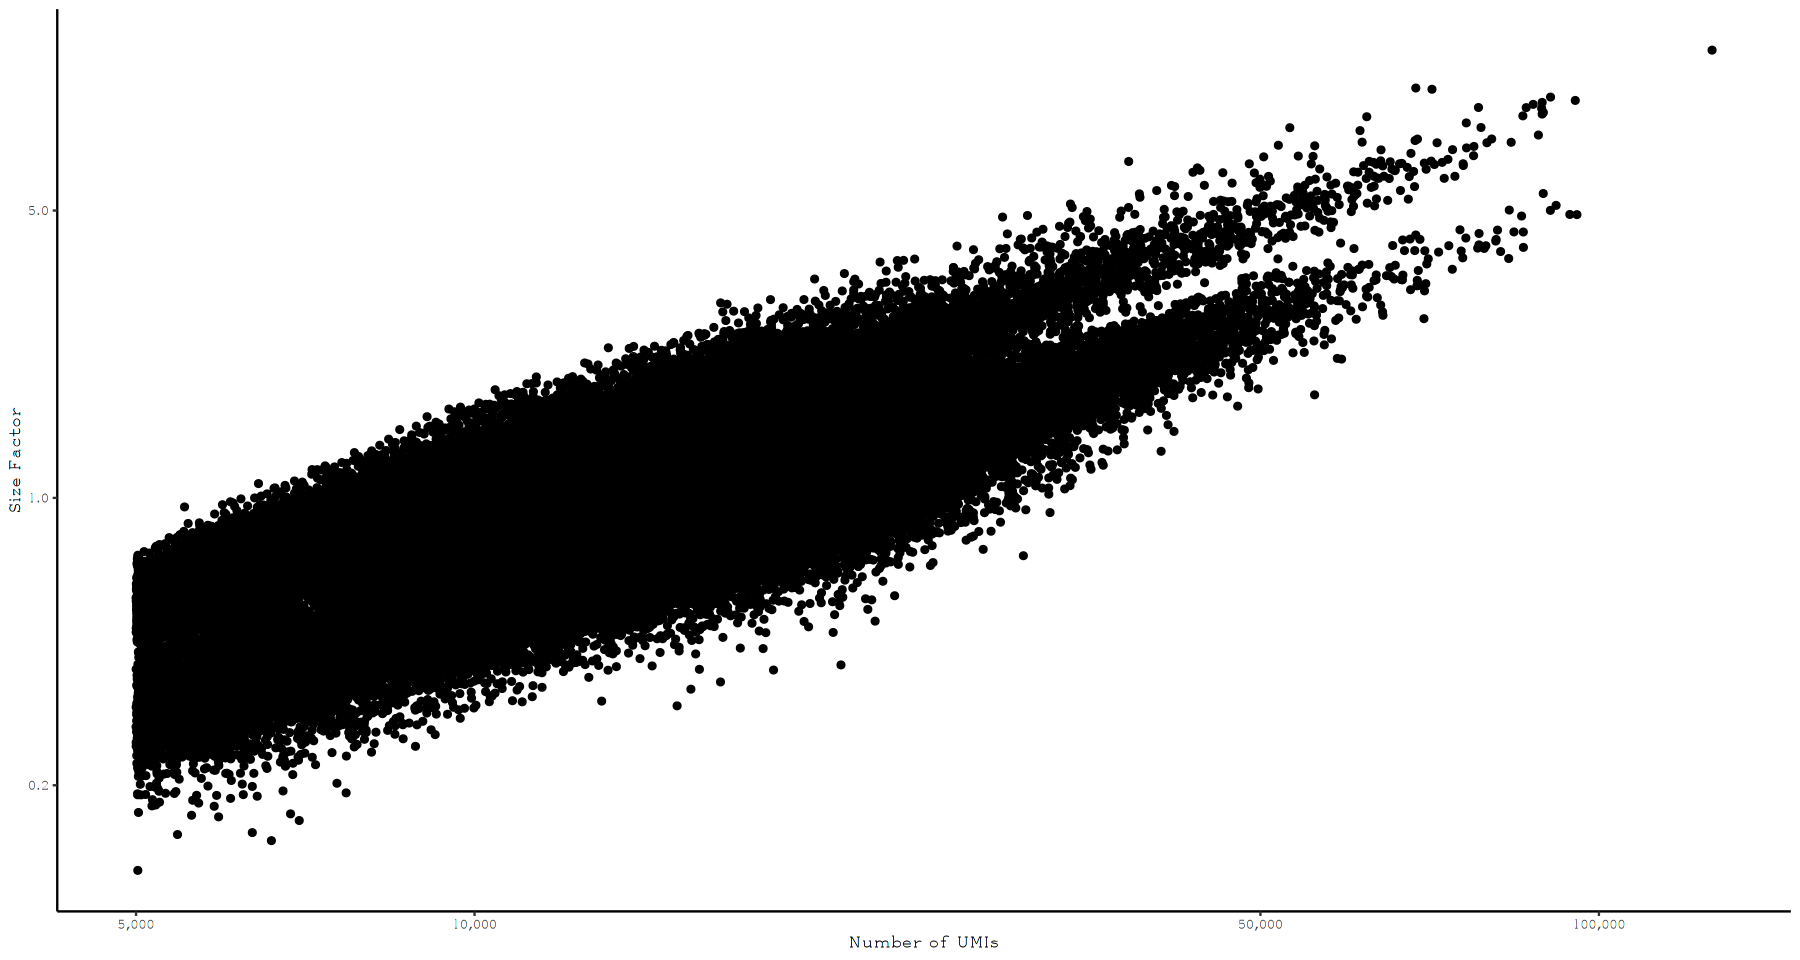

In [11]:
lib.sizes = Matrix::colSums(counts(big_sce))
ggplot(data = data.frame(X = lib.sizes, Y = sizeFactors(big_sce)),
              mapping = aes(x = X, y = Y)) +
  geom_point() +
  scale_x_log10(breaks = c(5000, 10000, 50000, 100000), labels = c("5,000", "10,000", "50,000", "100,000") ) +
  scale_y_log10(breaks = c(0.2, 1, 5)) +
  labs(x = "Number of UMIs", y = "Size Factor") + 
    theme_classic() + 
    theme(text = element_text(size=30))

In [12]:
# Normalize
sfs = read.table(paste0(out_dir,"sizefactors_big.tab"), stringsAsFactors = F)[,1]
sizeFactors(big_sce) = sfs
big_sce = scater::logNormCounts(big_sce)

# save normalized sce
saveRDS(big_sce, file = paste0(out_dir,"big_sce_norm.rds"))

In [189]:
big_sce = readRDS(paste0(out_dir,"big_sce_norm.rds"))

In [194]:
# perform PCA
hvgs = getHVGs(big_sce)
write.csv(hvgs, file =  paste0(out_dir,"big_hvgs.csv"))

big_pca = prcomp_irlba(t(logcounts(big_sce[hvgs,])), n = 50, scale.=TRUE)$x # scale. TRUE or FALSE?
rownames(big_pca) = colnames(big_sce) 
write.csv(big_pca, file =  paste0(out_dir,"big_pca_pre_batch_correction.csv"))

In [195]:
umap = run_umap(big_pca)

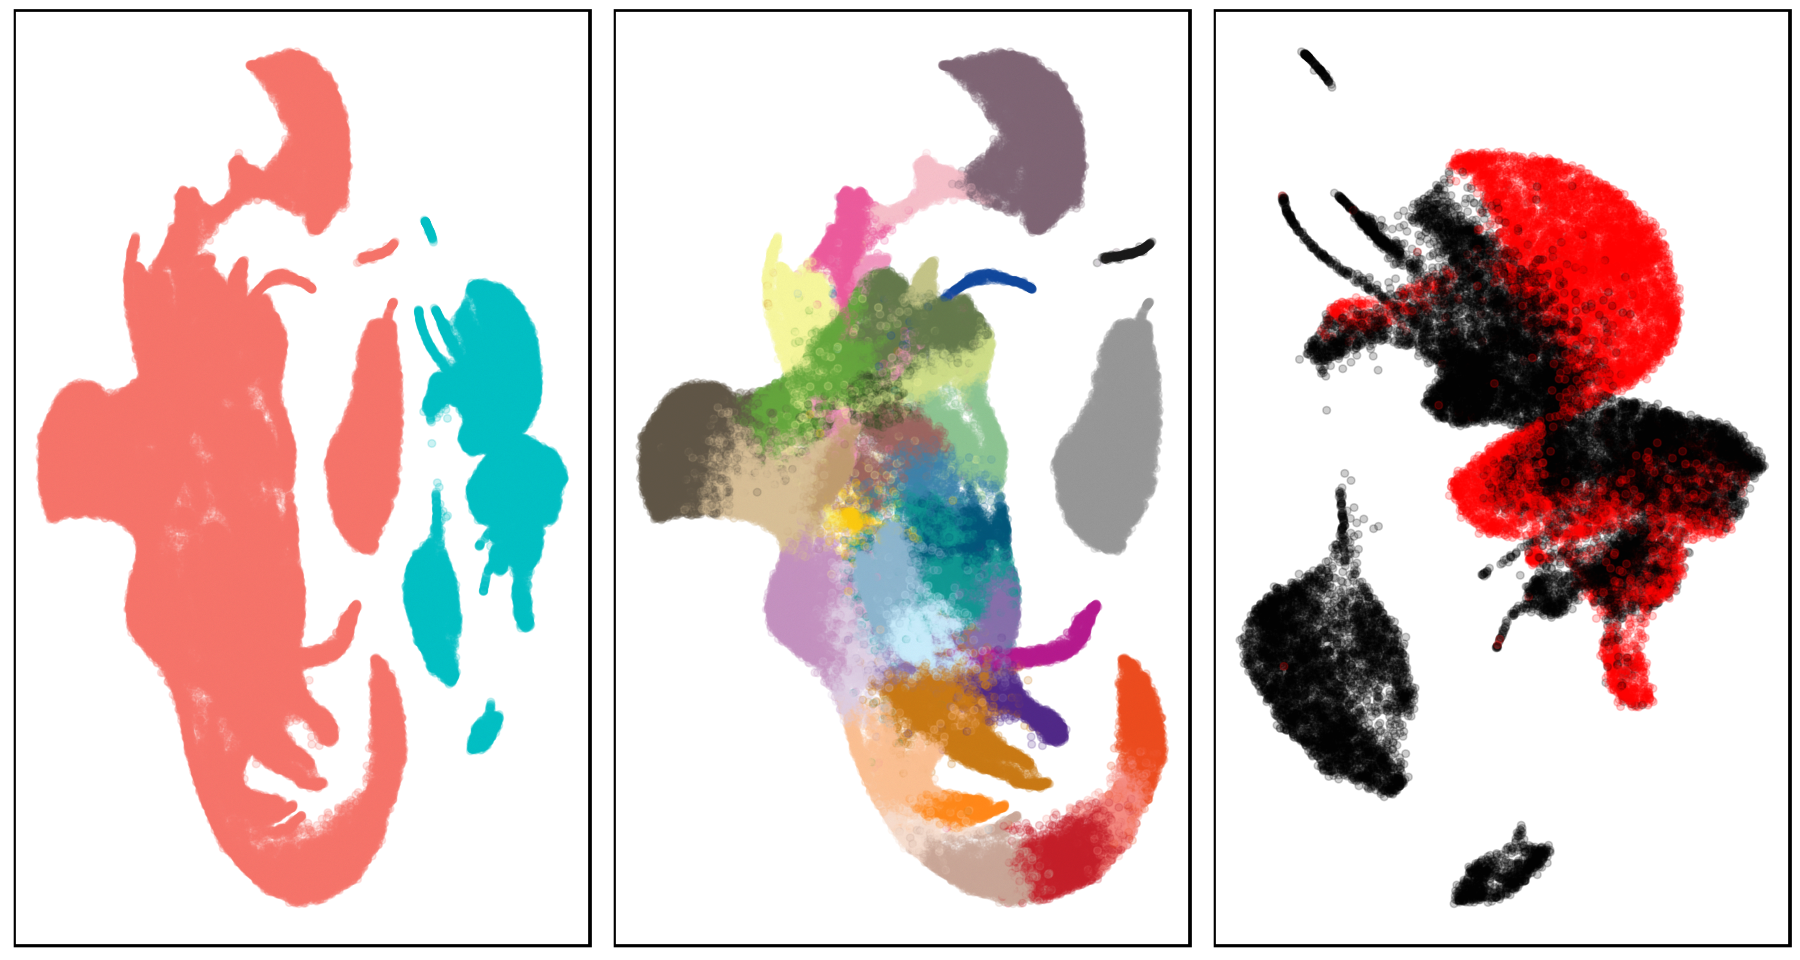

In [196]:
plot_umap(umap)

#### Very strong batch effect between atlas and chim datasets, but atlas itself is somewhat alright

In [33]:
head(atlas_meta)

,cell,barcode,sample,stage,sequencing.batch,theiler,doub.density,doublet,cluster,cluster.sub,...,haem_gephiY,haem_subclust,endo_gephiX,endo_gephiY,endo_trajectoryName,endo_trajectoryDPT,endo_gutX,endo_gutY,endo_gutDPT,endo_gutCluster
,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<dbl>,<lgl>,<int>,<int>,...,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,atlas_cell_1,AAAGGCCTCCACAA,1,E6.5,1,TS9,0.0431142,FALSE,2,4,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,atlas_cell_2,AACAAACTCGCCTT,1,E6.5,1,TS9,1.1297133,FALSE,12,1,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
5,atlas_cell_5,AACAGAGAATCAGC,1,E6.5,1,TS9,0.1121205,FALSE,3,7,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
6,atlas_cell_6,AACATATGAATCGC,1,E6.5,1,TS9,1.2547088,FALSE,1,1,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
8,atlas_cell_8,AACCGATGGCTTCC,1,E6.5,1,TS9,1.3457586,FALSE,2,1,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
9,atlas_cell_9,AACGTGTGCTCTAT,1,E6.5,1,TS9,1.1463686,FALSE,2,1,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [29]:
dim(sce)

[1] 29452 27986

# Multiple rounds of batch correction

In [8]:
big_pca = read.csv(paste0(out_dir,"big_pca_pre_batch_correction.csv"))
rownames(big_pca) = big_pca$X
big_pca$X = NULL

In [198]:
cells = rownames(big_pca)

In [199]:
load_data()
meta$cell <- paste0('chim_', meta$cell)
atlas_meta = read.table(paste0(atlas_in, 'meta.tab'), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
atlas_meta$cell <- paste0('atlas_', atlas_meta$cell)

In [200]:
atlas_meta = atlas_meta[atlas_meta$cell%in%cells,]
meta = meta[meta$cell%in%cells,]

In [201]:
meta_small = meta %>% select(cell, sample, stage)
meta_small$exp = 'eomes'
atlas_meta_small = atlas_meta %>% select(cell, sample, stage)
atlas_meta_small$exp = 'atlas'
big_meta = rbind(meta_small, atlas_meta_small)
big_meta$index = seq(1:nrow(big_meta))
big_meta$sample = paste0(big_meta$exp, '_', big_meta$sample)

In [210]:
write.csv(big_meta, paste0(out_dir, 'big_meta.csv'))

In [11]:
  #create nested list
  pc_list = lapply(unique(big_meta$exp), function(exp){
    sub_pc = big_pca[big_meta$exp == exp, , drop = FALSE]
    sub_meta = big_meta[big_meta$exp == exp,]
    list = lapply(unique(sub_meta$stage), function(tp){
      sub_pc[sub_meta$stage == tp, , drop = FALSE]
    })
    return(list)
  })

In [13]:
#perform corrections within list elements
correct_list = lapply(pc_list, function(x){
    if(length(x) > 1){
            lapply(x, function(y){
                cells = rownames(y)
                sub_meta = big_meta[big_meta$cell %in% cells, ]
                pca_corr = harmony::HarmonyMatrix(y, sub_meta, 'sample', do_pca = FALSE, verbose=FALSE)
                return(pca_corr)
    })}
       else {
              cells = rownames(x[[1]])
                sub_meta = big_meta[big_meta$cell %in% cells, ]
                pca_corr = harmony::HarmonyMatrix(x[[1]], sub_meta, 'sample', do_pca = FALSE, verbose=FALSE)
                return(pca_corr)
    }
    })

In [14]:
for(i in 1:length(correct_list)){
    if(class(correct_list[[i]])== 'list'){
    correct_list[[i]] = as.data.frame(do.call(rbind, correct_list[[i]]))

    meta_cells = big_meta[big_meta$cell%in%rownames(correct_list[[i]]),c(1,5)]
    correct_list[[i]] = correct_list[[i]][match(meta_cells$cell, row.names(correct_list[[i]])),]
}
    }

Warning message in if (class(correct_list[[i]]) == "list") {:
“the condition has length > 1 and only the first element will be used”


In [15]:
#perform corrections within list elements (i.e. within timepoints)
correct_list_tp = lapply(correct_list, function(x){
        cells = rownames(x)
        sub_meta = big_meta[big_meta$cell %in% cells, ]
        pca_corr = harmony::HarmonyMatrix(x, sub_meta, 'stage', do_pca = FALSE, verbose=FALSE)
    return(pca_corr)
})

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 5815600)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 5815600)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 5815600)”


In [16]:
correct_list_tp = do.call(rbind, correct_list_tp)
correct_list_tp = correct_list_tp[match(big_meta$cell, row.names(correct_list_tp)),]

In [17]:
#perform correction over between experiments
pca_corr = harmony::HarmonyMatrix(correct_list_tp, big_meta, 'exp', do_pca = FALSE, verbose=FALSE)

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 7214900)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 7214900)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 7214900)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 7214900)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 7214900)”


In [29]:
# check if PCs actually changed
head(pc_list[[2]][[1]],2)
head(correct_list[[2]],2)
head(correct_list_tp,2)
head(pca_corr,2)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48,PC49,PC50
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
atlas_cell_1,-15.23862,6.001802,2.434255,-9.740518,-5.732185,0.6643103,3.955652,2.126418,-0.727848,-2.71418812,...,-0.1901486,-1.0574857,-0.3082746,1.871809,0.8294172,-0.7949825,-0.0155123,-0.1244231,-0.7226903,0.5073453
atlas_cell_2,-16.03203,5.400579,3.354358,-8.346762,-5.927726,0.2434404,2.509437,-3.559448,-1.127699,0.06722343,...,1.3444820,0.4397948,0.4273423,-1.571596,-2.0942157,-0.4948303,0.2137784,-0.9857930,-0.1879366,-0.3041275


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48,PC49,PC50
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
atlas_cell_1,-15.50473,6.118989,2.004177,-9.526521,-5.870294,0.6558523,3.696973,1.779733,-0.6625541,-2.84638928,...,-0.1327791,-0.8237281,-0.9496706,1.500402,1.305446,-1.0188809,-0.17576695,-0.1967544,-1.0895452,0.3381996
atlas_cell_2,-16.29814,5.517765,2.924280,-8.132765,-6.065835,0.2349824,2.250757,-3.906133,-1.0624049,-0.06497768,...,1.4018514,0.6735524,-0.2140537,-1.943003,-1.618187,-0.7187286,0.05352375,-1.0581244,-0.5547915,-0.4732731


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48,PC49,PC50
chim_cell_1,72.50000,-1.2037529,0.468991625,0.4386121,0.11292385,1.8705185,0.4451417,-0.05657828,-1.19514418,0.65951941,...,0.6999328,0.9198971,0.3828452,0.7214879,-0.3270942,0.54798052,-0.5883893,-0.3719301,-0.1196894,1.450920
chim_cell_2,66.02274,-0.1688481,-0.004419622,-0.2372456,-0.05667824,-0.8408053,0.3414024,-0.07981473,-0.03211006,-0.08629405,...,-0.4051857,-0.7465984,-0.1518472,-0.5261948,0.2554548,-0.04046835,0.5927919,0.1008257,0.1992067,-1.666422


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48,PC49,PC50
chim_cell_1,67.92570,-1.3717089,-0.0245947,0.03701798,0.8082218,1.9248813,0.6407685,-0.02817268,-0.7957114,0.4571523,...,0.5861483,1.0178709,0.44281815,0.6521685,-0.54180325,0.4870589,-0.5650941,-0.01284956,-0.24494232,1.562605
chim_cell_2,61.44844,-0.3368042,-0.4980060,-0.63883977,0.6386197,-0.7864426,0.5370292,-0.05140914,0.3673227,-0.2886611,...,-0.5189702,-0.6486247,-0.09187425,-0.5955142,0.04074574,-0.1013900,0.6160872,0.45990631,0.07395377,-1.554736


In [18]:
umap = run_umap(pca_corr)

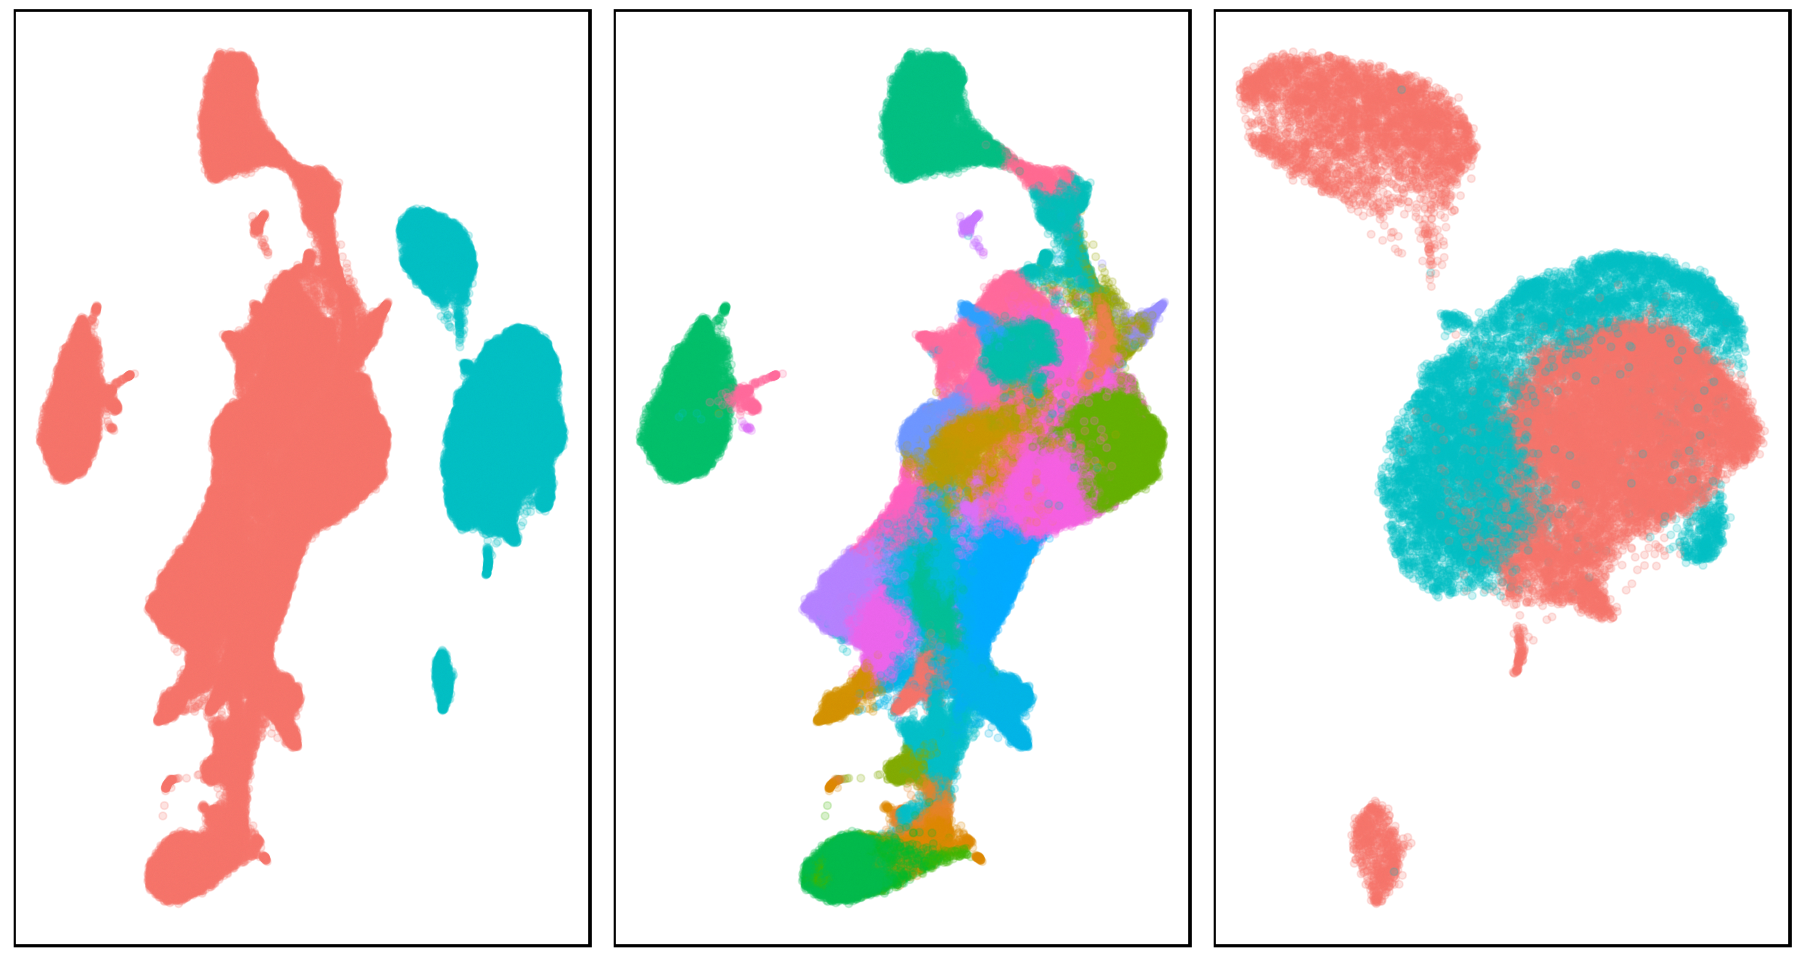

In [19]:
plot_umap(umap)

In [20]:
write.csv(pca_corr, file =  paste0(out_dir,"big_pca_post_3_batch_correction.csv"))

# Batch correction multiple covariates

In [111]:
big_meta$sample = as.factor(big_meta$sample)
big_meta$stage = as.factor(big_meta$stage)
big_meta$exp = as.factor(big_meta$exp)

In [113]:
pca_corr = harmony::HarmonyMatrix(big_pca, big_meta, c("sample", "stage", "exp"), do_pca = FALSE, verbose=FALSE)

In [114]:
umap = run_umap(pca_corr)


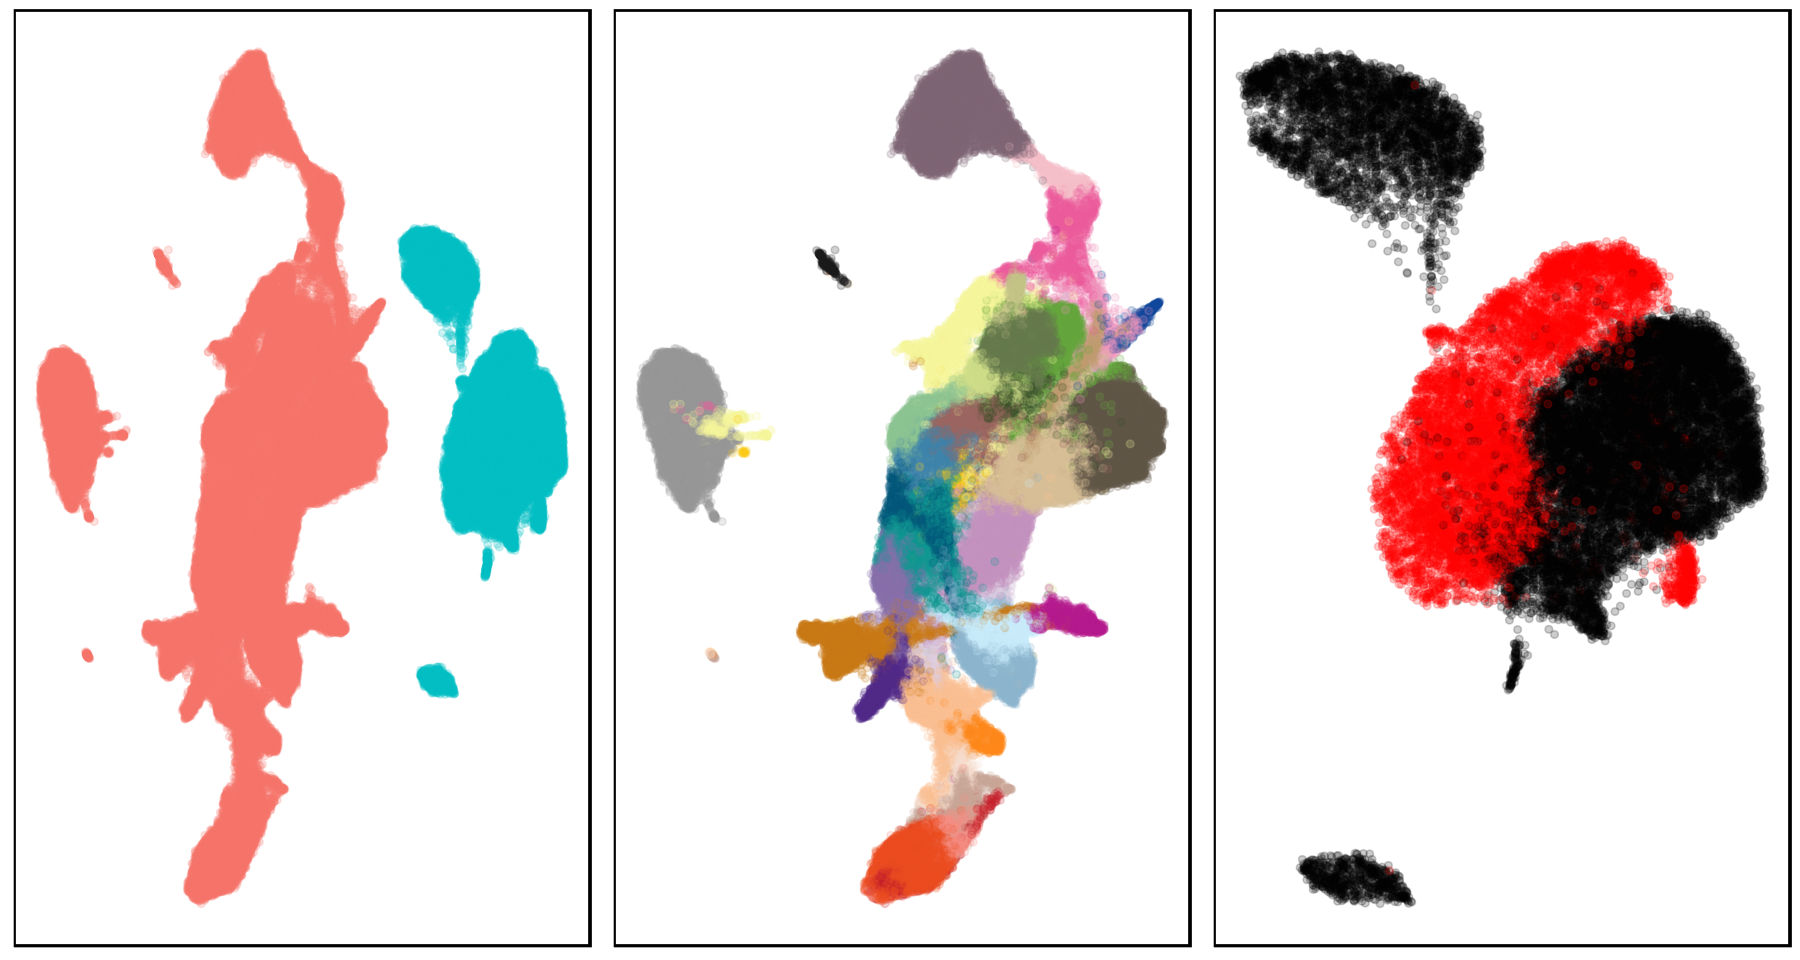

In [115]:
plot_umap(umap)

In [105]:
class(big_meta$stage)

[1] "character"

# Single round of batch correction

In [5]:
big_pca = read.csv(paste0(out_dir,"big_pca_pre_batch_correction.csv"))
rownames(big_pca) = big_pca$X
big_pca$X = NULL

In [6]:
load_data()
meta$cell <- paste0('chim_', meta$cell)
atlas_meta = read.table(paste0(atlas_in, 'meta.tab'), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
atlas_meta$cell <- paste0('atlas_', atlas_meta$cell)

In [7]:
atlas_meta = atlas_meta[atlas_meta$cell%in%cells,]
meta = meta[meta$cell%in%cells,]

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'table' in selecting a method for function '%in%': object 'cells' not found


In [ ]:
meta_small = meta %>% select(cell, sample, stage)
meta_small$exp = 'eomes'
atlas_meta_small = atlas_meta %>% select(cell, sample, stage)
atlas_meta_small$exp = 'atlas'
big_meta = rbind(meta_small, atlas_meta_small)
big_meta$index = seq(1:nrow(big_meta))

In [ ]:
big_meta$sample = paste0(big_meta$exp, '_', big_meta$sample)

In [191]:
pca_corr = harmony::HarmonyMatrix(big_pca, big_meta, 'sample', do_pca = FALSE, verbose=FALSE)

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 7214900)”


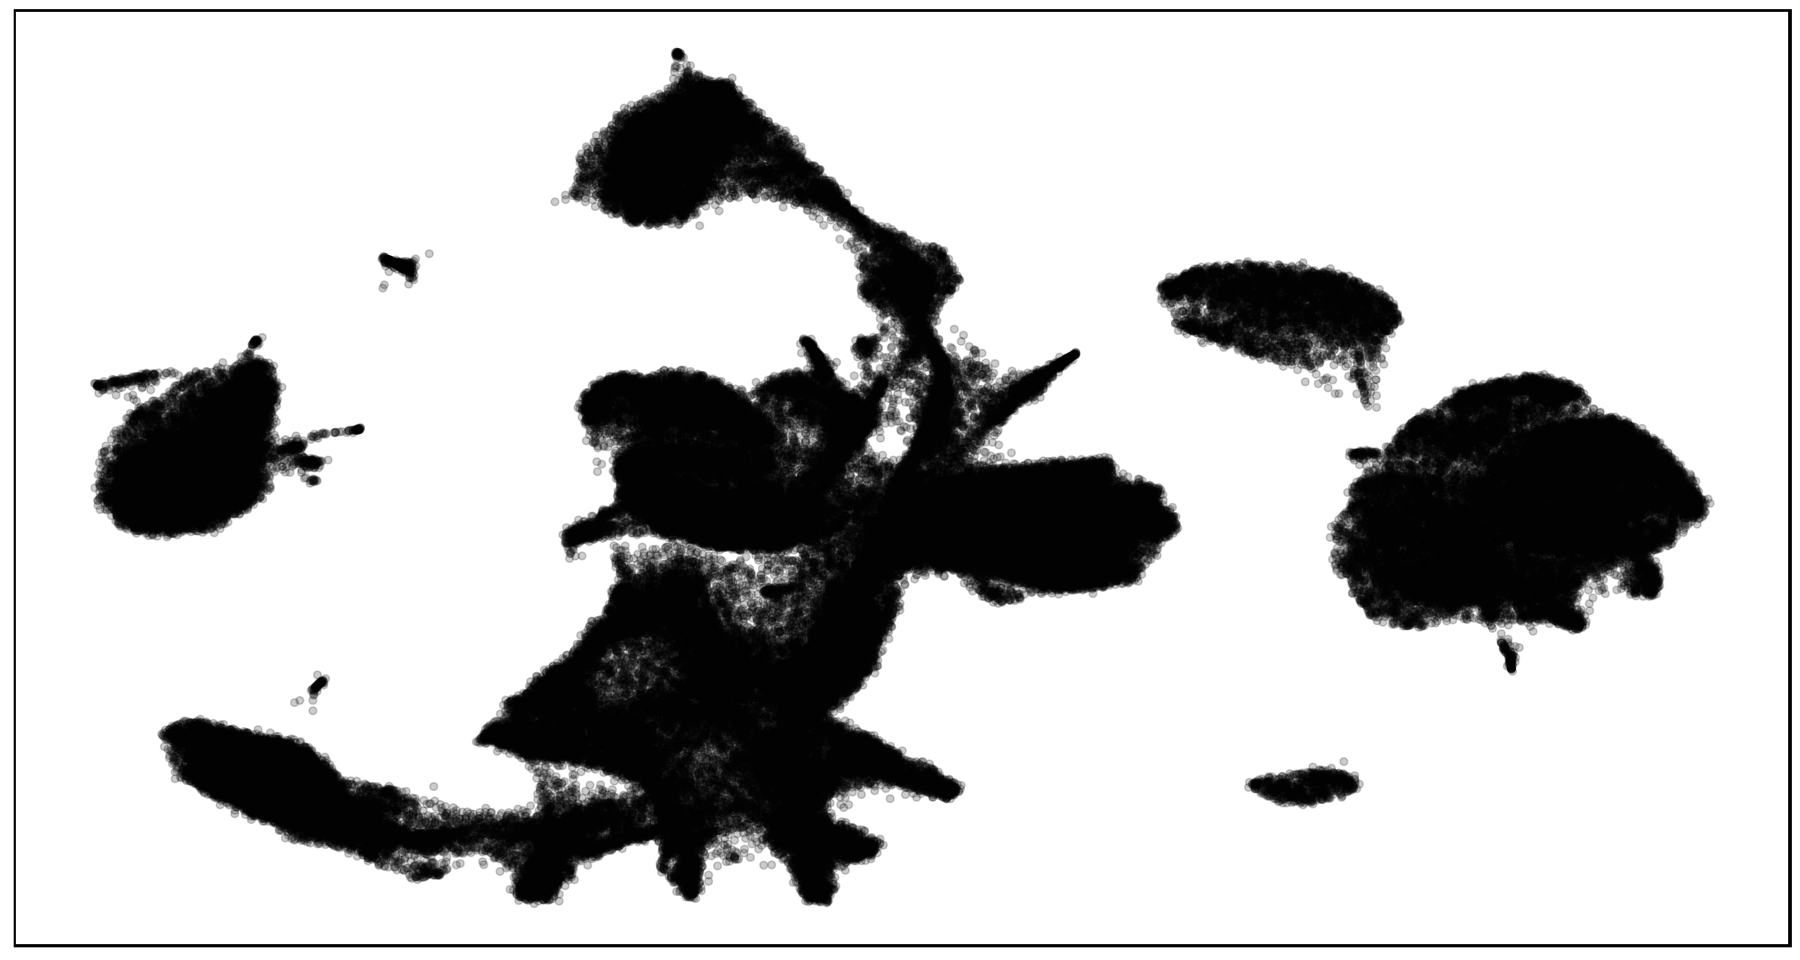

In [195]:
umap = run_umap(pca_corr)

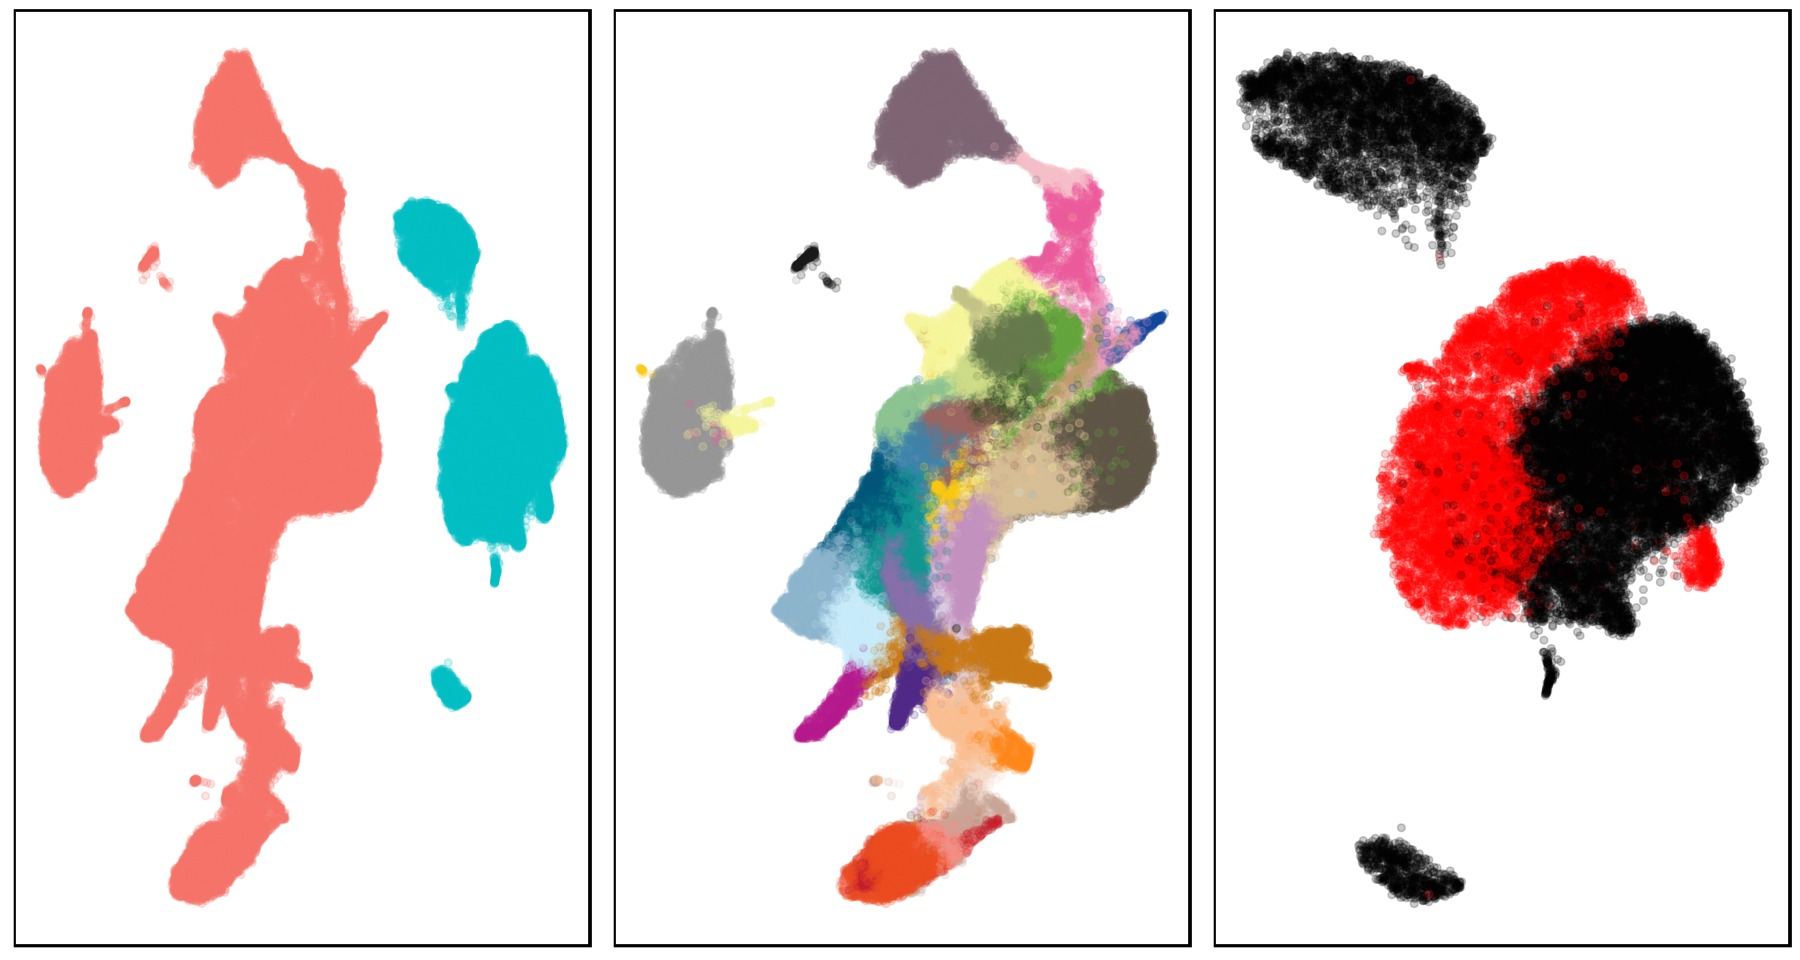

In [95]:
plot_umap(umap)

# two rounds of batch correction

In [197]:
big_pca = read.csv(paste0(out_dir,"big_pca_pre_batch_correction.csv"))
rownames(big_pca) = big_pca$X
big_pca$X = NULL

In [198]:
load_data()
meta$cell <- paste0('chim_', meta$cell)
atlas_meta = read.table(paste0(atlas_in, 'meta.tab'), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
atlas_meta$cell <- paste0('atlas_', atlas_meta$cell)

In [199]:
atlas_meta = atlas_meta[atlas_meta$cell%in%cells,]
meta = meta[meta$cell%in%cells,]

In [200]:
meta_small = meta %>% select(cell, sample, stage)
meta_small$exp = 'eomes'
atlas_meta_small = atlas_meta %>% select(cell, sample, stage)
atlas_meta_small$exp = 'atlas'
big_meta = rbind(meta_small, atlas_meta_small)
big_meta$index = seq(1:nrow(big_meta))

In [201]:
big_meta$sample = paste0(big_meta$exp, '_', big_meta$sample)

In [202]:
  #create list
  pc_list = lapply(unique(big_meta$exp), function(exp){
    sub_pc = big_pca[big_meta$exp == exp, , drop = FALSE]
      return(sub_pc)
    })


In [205]:
tail(big_meta)

,cell,sample,stage,exp,index
,<chr>,<chr>,<chr>,<chr>,<int>
139325,atlas_cell_139325,atlas_37,E8.5,atlas,144293
139326,atlas_cell_139326,atlas_37,E8.5,atlas,144294
139327,atlas_cell_139327,atlas_37,E8.5,atlas,144295
139329,atlas_cell_139329,atlas_37,E8.5,atlas,144296
139330,atlas_cell_139330,atlas_37,E8.5,atlas,144297
139331,atlas_cell_139331,atlas_37,E8.5,atlas,144298


In [206]:
#perform corrections within list elements (i.e. within timepoints)
correct_list = lapply(pc_list, function(x){
        cells = rownames(x)
        sub_meta = big_meta[big_meta$cell %in% cells, ]
        pca_corr = harmony::HarmonyMatrix(x, sub_meta, 'sample', do_pca = FALSE, verbose=FALSE)
    return(pca_corr)
})

Warning message:
“did not converge in 25 iterations”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 5815600)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 5815600)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 5815600)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 5815600)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 5815600)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 5815600)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 5815600)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 5815600)”


ERROR: Error in harmonize(harmonyObj, max.iter.harmony, verbose): terminated by user


In [ ]:
correct_list_exp = do.call(rbind, correct_list)
correct_list_exp = correct_list_exp[match(big_meta$cell, row.names(correct_list_exp)),]

In [ ]:
#perform correction over between experiments
pca_corr = harmony::HarmonyMatrix(correct_list_exp, big_meta, 'exp', do_pca = FALSE, verbose=FALSE)

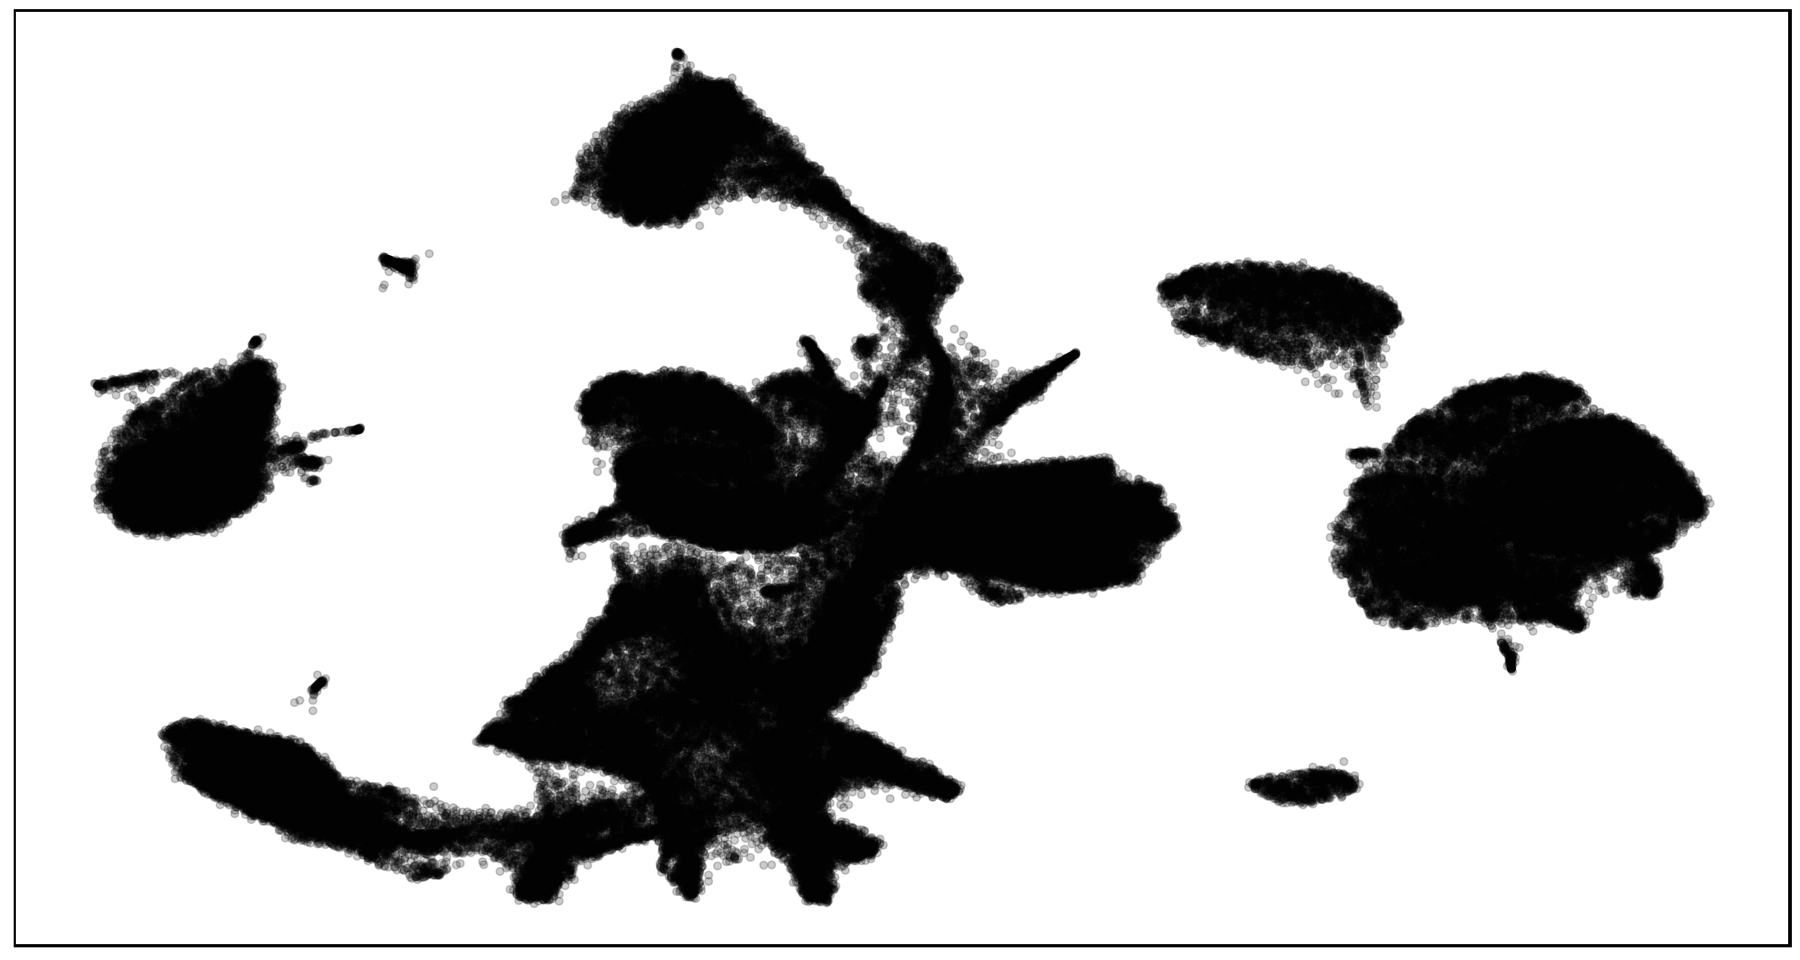

In [195]:
umap = run_umap(pca_corr)

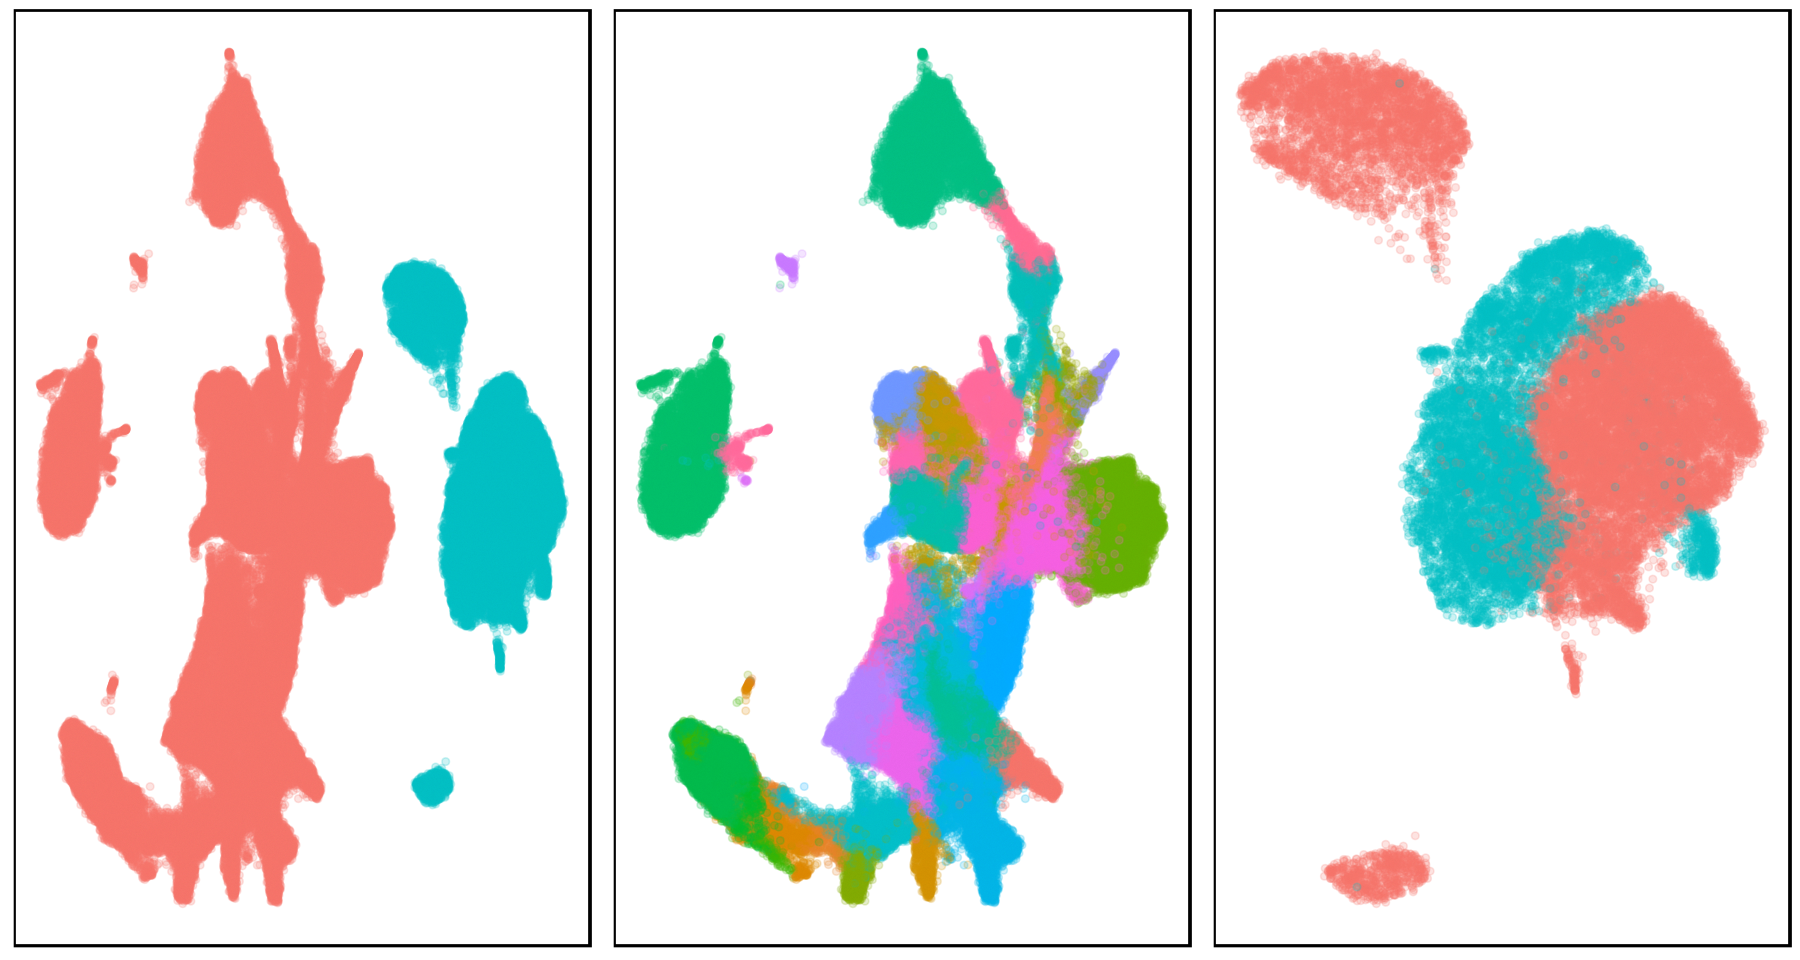

In [196]:
plot_umap(umap)

In [ ]:
write.csv(pca_corr, file =  paste0(out_dir,"big_pca_post_2_batch_correction.csv"))

# TEST

In [202]:
chim = big_meta %>% filter(exp == 'eomes' |stage %in% c('E8.25') )
chim_pca = big_pca[chim$cell, ]

In [203]:
tdtom = data.frame('tdTom' = unique(meta$tdTom), 'sample' = unique(meta$sample))
tdtom$sample = paste0('eomes_', tdtom$sample)
chim = merge(chim, tdtom, by= 'sample', all.x=TRUE)

In [204]:
chim = chim[order(chim$index), ]

In [205]:
chim_pca = chim_pca[, 1:20]

In [206]:
rownames(chim) = chim$cell

In [207]:
class(as.matrix(chim_pca))

[1] "matrix" "array"

In [208]:
harmony_embeddings <- harmony::HarmonyMatrix(
    as.matrix(chim_pca), chim$sample, do_pca = FALSE, verbose=FALSE
)

Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony converged after 3 iterations



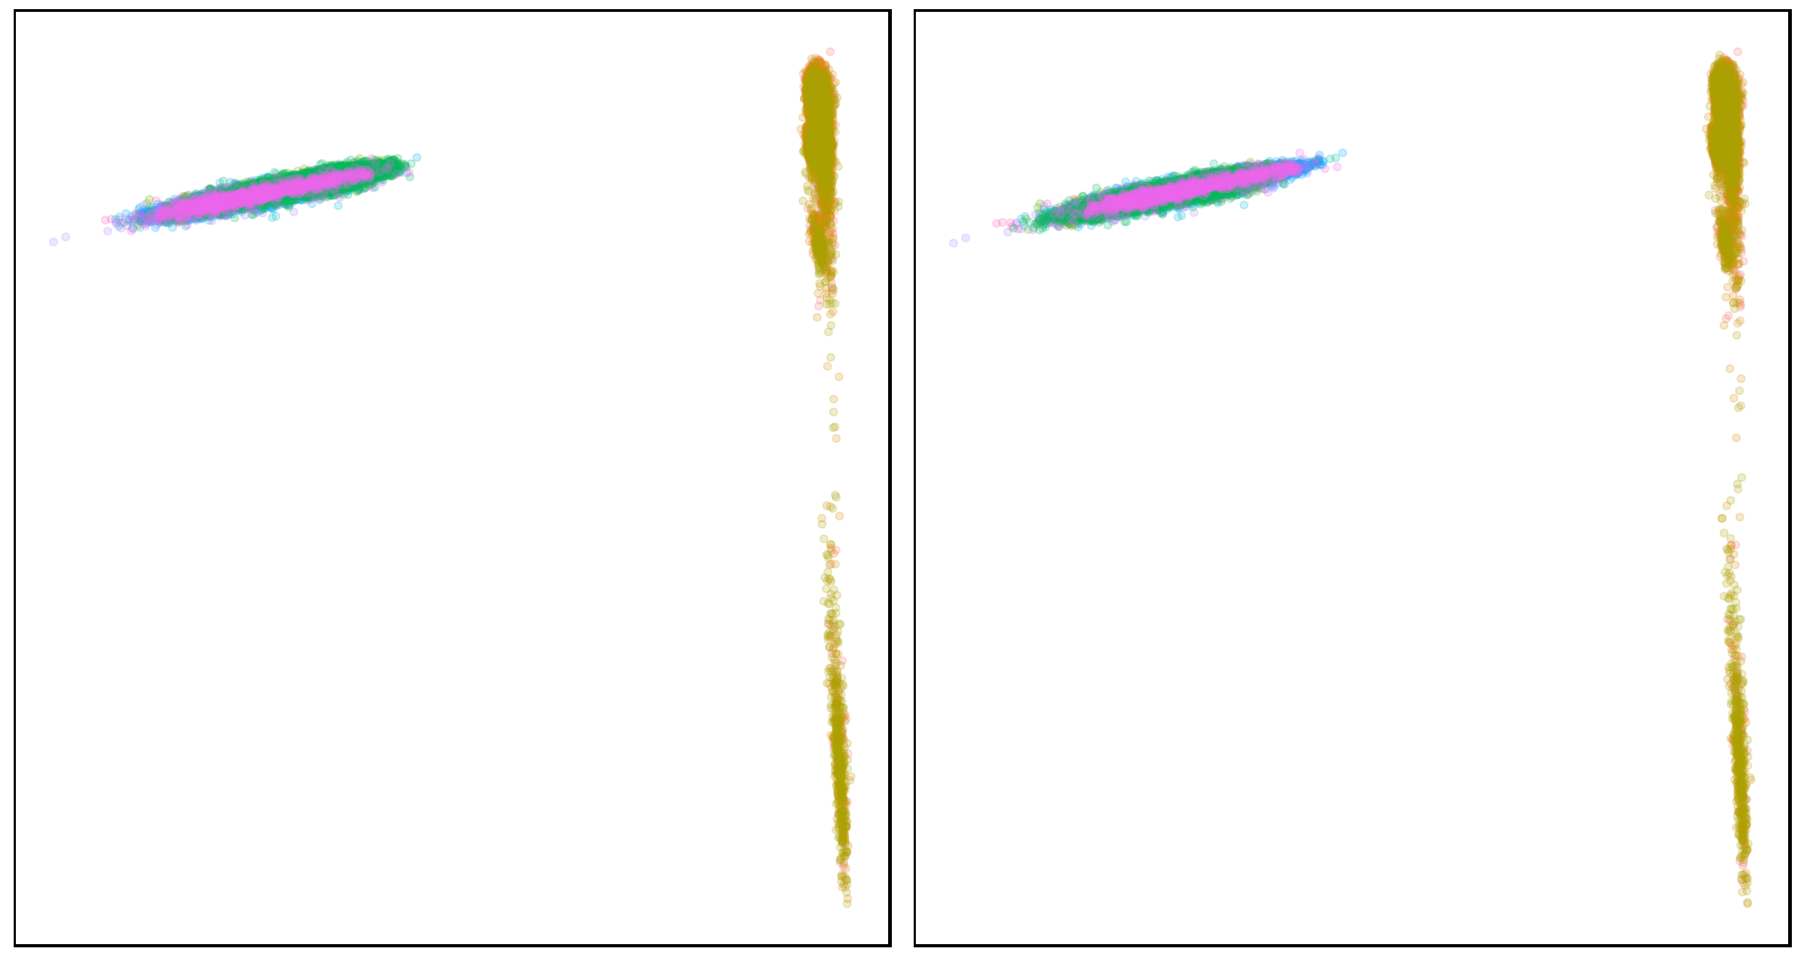

In [209]:
p1 = ggplot(chim_pca, aes(PC1, PC2, col = chim$sample)) + 
        geom_point(alpha = 0.2) + 
     #   scale_colour_manual(values = c('negative' = 'black', 'positive' = 'red'), name = "Tomato") + 
        theme(text = element_text(size = 30),
                axis.text.y   = element_blank(),
                axis.text.x   = element_blank(),
                axis.title.y  = element_blank(),
                axis.title.x  = element_blank(),
                axis.ticks = element_blank(),
                legend.position = "none",
                panel.background = element_blank(),
                panel.grid.major = element_blank(), 
                panel.grid.minor = element_blank(),
                panel.border = element_rect(colour = "black", fill=NA, size=1)) +
        guides(colour = guide_legend(override.aes = list(alpha = 1)))

p2 = ggplot(as.data.frame(harmony_embeddings), aes(PC1, PC2, col = chim$sample)) + 
        geom_point(alpha = 0.2) + 
     #   scale_colour_manual(values = c('negative' = 'black', 'positive' = 'red'), name = "Tomato") + 
        theme(text = element_text(size = 30),
                axis.text.y   = element_blank(),
                axis.text.x   = element_blank(),
                axis.title.y  = element_blank(),
                axis.title.x  = element_blank(),
                axis.ticks = element_blank(),
                legend.position = "none",
                panel.background = element_blank(),
                panel.grid.major = element_blank(), 
                panel.grid.minor = element_blank(),
                panel.border = element_rect(colour = "black", fill=NA, size=1)) +
        guides(colour = guide_legend(override.aes = list(alpha = 1)))

grid.arrange(p1, p2, ncol = 2)

In [149]:
class(chim$tdTom)
class(chim$exp)

[1] "character"

[1] "character"

In [185]:
umap = run_umap(chim_pca)

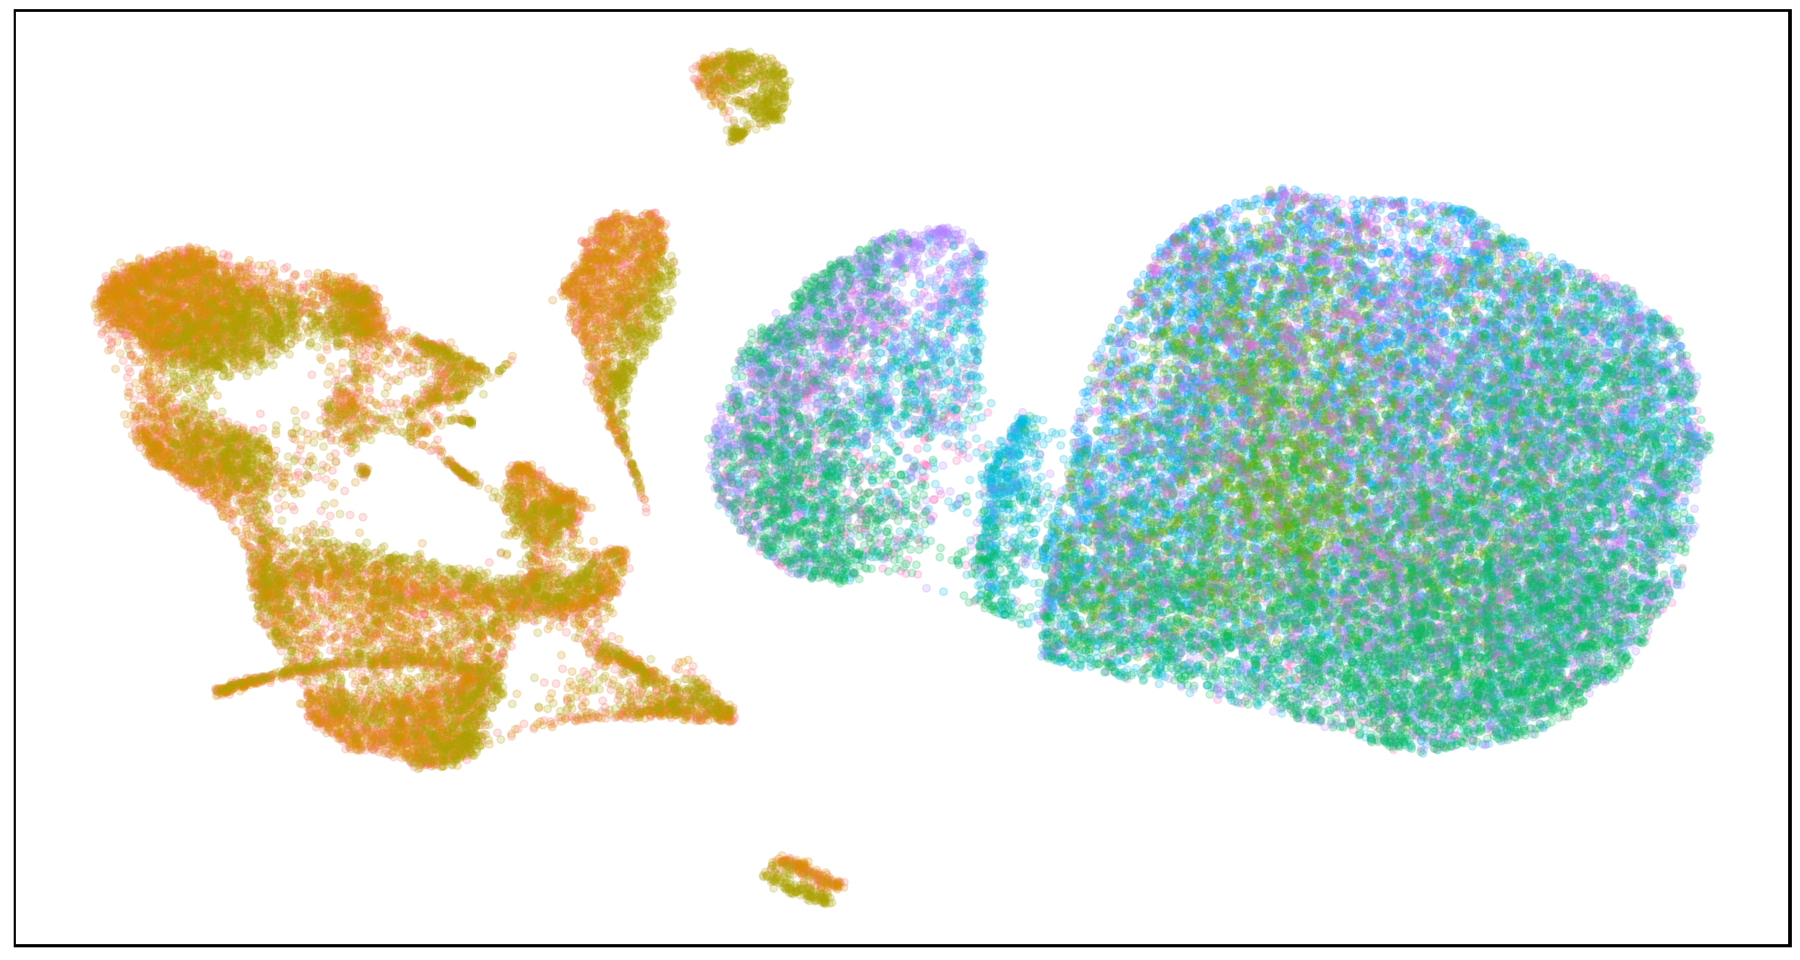

In [186]:
ggplot(umap, aes(umap_1, umap_2, col = chim$sample)) + 
        geom_point(alpha = 0.2) + 
     #   scale_colour_manual(values = c('negative' = 'black', 'positive' = 'red'), name = "Tomato") + 
        theme(text = element_text(size = 30),
                axis.text.y   = element_blank(),
                axis.text.x   = element_blank(),
                axis.title.y  = element_blank(),
                axis.title.x  = element_blank(),
                axis.ticks = element_blank(),
                legend.position = "none",
                panel.background = element_blank(),
                panel.grid.major = element_blank(), 
                panel.grid.minor = element_blank(),
                panel.border = element_rect(colour = "black", fill=NA, size=1)) +
        guides(colour = guide_legend(override.aes = list(alpha = 1)))

In [187]:
umap = run_umap(harmony_embeddings)

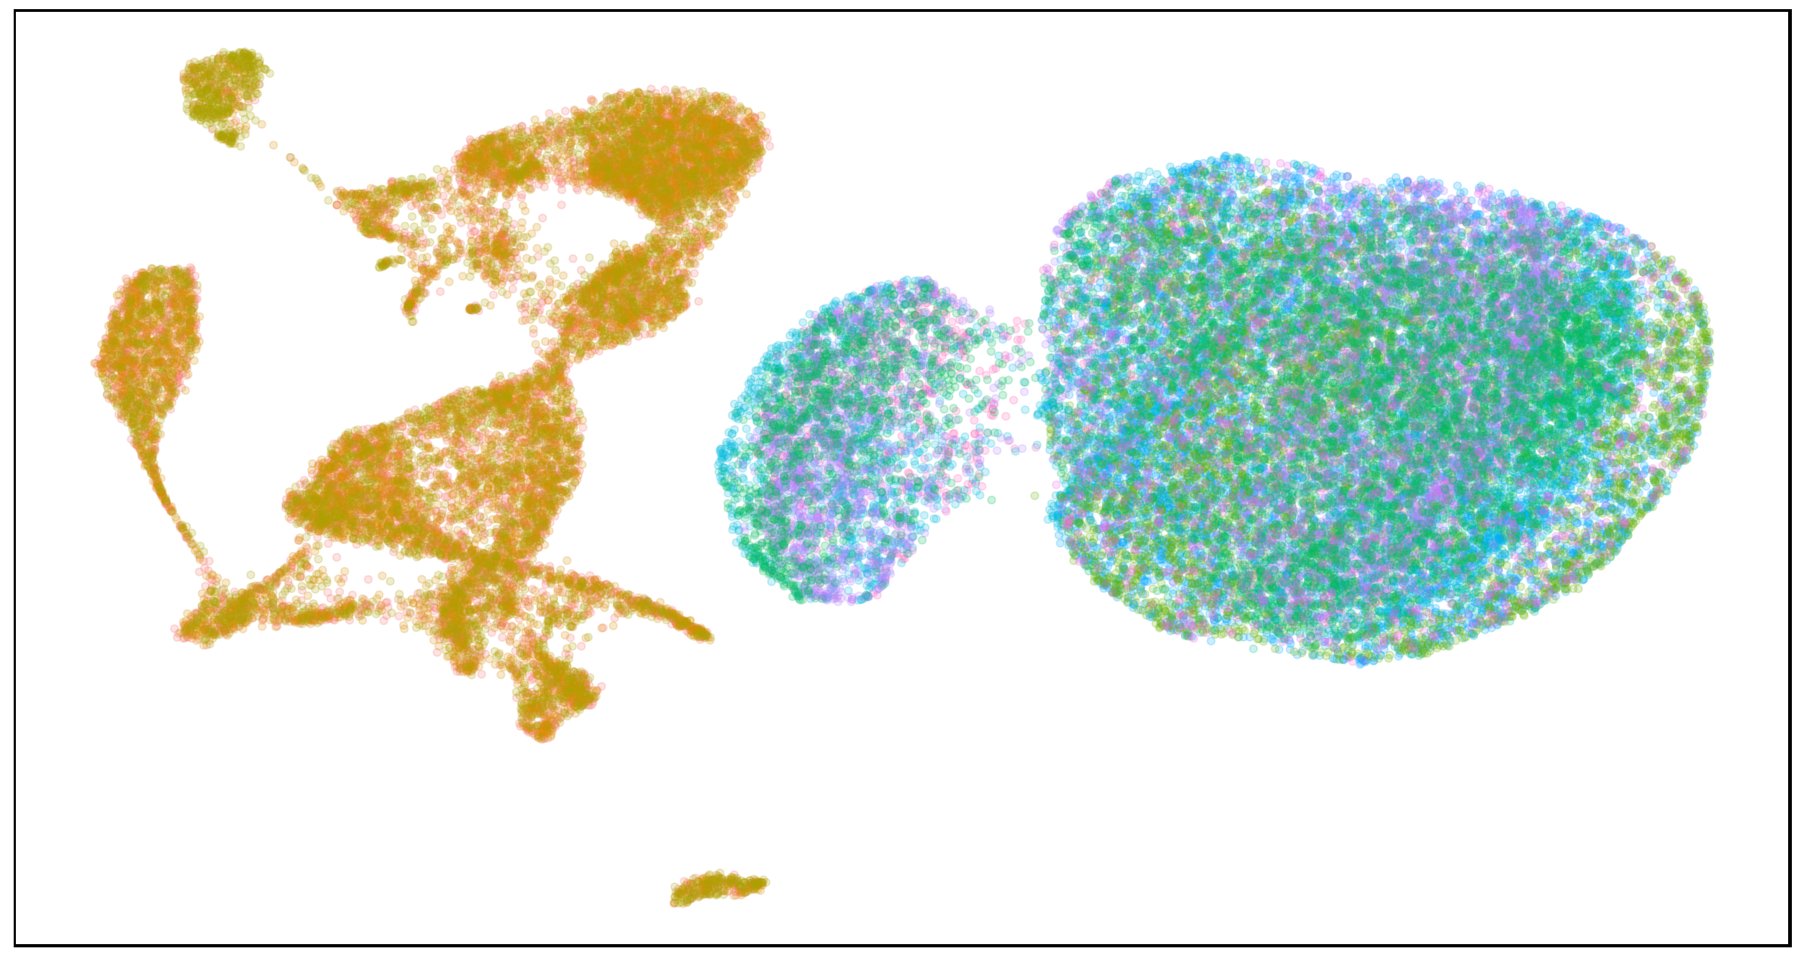

In [188]:
ggplot(umap, aes(umap_1, umap_2, col = chim$sample)) + 
        geom_point(alpha = 0.2) + 
     #   scale_colour_manual(values = c('negative' = 'black', 'positive' = 'red'), name = "Tomato") + 
        theme(text = element_text(size = 30),
                axis.text.y   = element_blank(),
                axis.text.x   = element_blank(),
                axis.title.y  = element_blank(),
                axis.title.x  = element_blank(),
                axis.ticks = element_blank(),
                legend.position = "none",
                panel.background = element_blank(),
                panel.grid.major = element_blank(), 
                panel.grid.minor = element_blank(),
                panel.border = element_rect(colour = "black", fill=NA, size=1)) +
        guides(colour = guide_legend(override.aes = list(alpha = 1)))

In [2]:
sessionInfo()

R version 4.0.3 (2020-10-10)
Platform: x86_64-pc-linux-gnu (64-bit)
Running under: Manjaro Linux

Matrix products: default
BLAS:   /usr/local/lib64/R/lib/libRblas.so
LAPACK: /usr/local/lib64/R/lib/libRlapack.so

locale:
 [1] LC_CTYPE=en_GB.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_GB.UTF-8        LC_COLLATE=en_GB.UTF-8    
 [5] LC_MONETARY=en_GB.UTF-8    LC_MESSAGES=en_GB.UTF-8   
 [7] LC_PAPER=en_GB.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_GB.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] parallel  stats4    stats     graphics  grDevices utils     datasets 
[8] methods   base     

other attached packages:
 [1] gridExtra_2.3               dplyr_1.0.4.9000           
 [3] data.table_1.13.6           reticulate_1.18            
 [5] harmony_1.0                 Rcpp_1.0.6                 
 [7] scran_1.18.1                knitr_1.30                 
 [9] reshape2_1.4.4              